### Tommie Ferrero – MNIST klassificering av handskrivna siffror

I denna notebook genomför jag ett komplett ML-flöde för MNIST:
- laddar och utforskar datan (EDA),
- delar upp i träning, validering och test,
- tränar och utvärderar minst två modeller,
- väljer en bästa modell och utvärderar den på testdatan,
- sparar modellen inför en Streamlit-applikation.

### Steg 1 – Ladda bibliotek


Här importerar jag:
- standardbibliotek (numpy, pandas, matplotlib),
- scikit-learn för datasplit, skalning, modeller och utvärderingsmått,
- scipy.stats för slumpmässig hyperparametersökning,
- joblib för att spara den färdiga modellen.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import joblib

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import ExtraTreesClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

from scipy.stats import randint

Skapar en funktion som senare används för att visualisera confusion matrix.

In [2]:
def display_confusion_matrix(y_true, y_pred, title=None):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues", values_format="d")
    if title:
        plt.title(title)
    plt.show()

### Steg 2 – Ladda MNIST-datasetet

Här laddar jag MNIST (70 000 bilder) från openml.

- Varje bild har 28×28 = 784 pixlar.
- Varje etikett är en siffra 0–9.

In [3]:
mnist = fetch_openml("mnist_784", version=1, cache=True, as_frame=False)

X = mnist["data"] # (70000, 784)
y = mnist["target"].astype(int) # omvandla etiketter till heltal

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unika etiketter:", np.unique(y))

X shape: (70000, 784)
y shape: (70000,)
Unika etiketter: [0 1 2 3 4 5 6 7 8 9]


Visualisera exempel och label-fördelning.


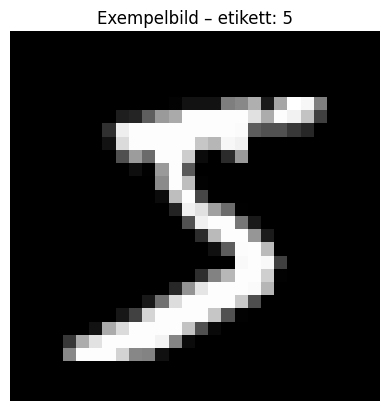

Siffra 0: 6903 exempel
Siffra 1: 7877 exempel
Siffra 2: 6990 exempel
Siffra 3: 7141 exempel
Siffra 4: 6824 exempel
Siffra 5: 6313 exempel
Siffra 6: 6876 exempel
Siffra 7: 7293 exempel
Siffra 8: 6825 exempel
Siffra 9: 6958 exempel


In [4]:
# visa ett exempel
index = 0
some_digit = X[index].reshape(28, 28)
some_label = y[index]

plt.imshow(some_digit, cmap="gray")
plt.title(f"Exempelbild – etikett: {some_label}")
plt.axis("off")
plt.show()

# label-fördelning
classes, counts = np.unique(y, return_counts=True)
for c, cnt in zip(classes, counts):
    print(f"Siffra {c}: {cnt} exempel")

Kommentar – EDA på MNIST

- Datasetet innehåller 70 000 bilder med 784 pixlar vardera, vilket motsvarar 28×28 gråskalepixlar per bild.
- Etiketterna går från 0 till 9 och fördelningen är relativt jämn (ca 6 000–7 800 exempel per siffra), vilket betyder att datasetet är balanserat.
- Exempelbilden (etikett 5) visar en vit siffra mot svart bakgrund, vilket stämmer med beskrivningen av MNIST i kursmaterialet (Lär dig AI från grunden, boken).


### Steg 3 – Dela upp i träning, validering och test


Här delas alla 70 000 observationer i:
- träningsdata + valideringsdata (X_train_val, y_train_val)
- testdata (X_test, y_test)

Sedan delas träningsdelen vidare i:
- ren träningsdata (X_train, y_train)
- valideringsdata (X_val, y_val)

Tränings- och valideringsdatan standardiseras med StandardScaler.
Testdatan skalas separat i Steg 6 när scalern refittas på train+val.

In [5]:
# först: train_val + test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=10000,
    random_state=42,
    stratify=y
)

# sedan: train + val
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=10000,
    random_state=42,
    stratify=y_train_val
)

print("Train", X_train.shape, y_train.shape)
print("Val", X_val.shape, y_val.shape)
print("Test", X_test.shape, y_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

Train (50000, 784) (50000,)
Val (10000, 784) (10000,)
Test (10000, 784) (10000,)


Fler exempelbilder ur datat, för en utökad översikt av hur de handskrivna siffrorna ser ut. 

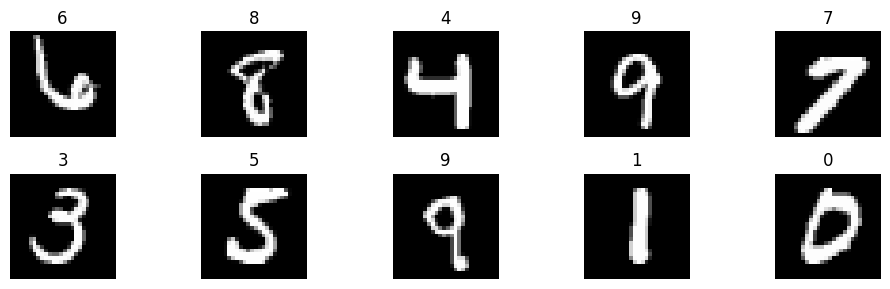

In [6]:
# visa flera exempelbilder från träningsdatan
num_images = 10  # antal

plt.figure(figsize=(10, 3))
for i in range(num_images):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    plt.title(int(y_train[i]))
plt.tight_layout()
plt.show()

### Steg 4 - Träning av modeller
- Modell 1: Logistic Regression (baseline)

- Modell 2: Extra Trees


Först tränas en enkel linjär modell (logistisk regression).
Den fungerar som baseline att jämföra mer avancerade modeller mot.

In [7]:
logreg_clf = LogisticRegression(max_iter=1000, n_jobs=-1)
logreg_clf.fit(X_train_scaled, y_train)

y_val_pred_logreg = logreg_clf.predict(X_val_scaled)
logreg_val_acc = accuracy_score(y_val, y_val_pred_logreg)

print(f"Val-accuracy Logistic Regression: {logreg_val_acc:.4f}")

c:\Users\tommi_bdmz4mu\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Val-accuracy Logistic Regression: 0.9165


Här tränas en ExtraTreesClassifier, som är en ensemble av beslutsträd.
Den kan fånga icke-linjära mönster i pixlarna bättre än en linjär modell.

In [8]:
et_clf = ExtraTreesClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
et_clf.fit(X_train_scaled, y_train)

y_val_pred_et = et_clf.predict(X_val_scaled)
et_val_acc = accuracy_score(y_val, y_val_pred_et)

print(f"Val-accuracy Extra Trees: {et_val_acc:.4f}")

Val-accuracy Extra Trees: 0.9739


För att hitta bättre hyperparametrar för Extra Trees används RandomizedSearchCV.
Istället för att testa alla möjliga kombinationer söker den slumpmässigt bland
angivna värden – ett effektivt sätt att förbättra modellen utan att det tar evigheter.

Sökningen görs på träningsdatan med 3-fold cross-validation, och den bästa
modellen utvärderas sedan på valideringsdatan.

In [9]:
# bas-modell att söka ifrån
base_et = ExtraTreesClassifier(random_state=42, n_jobs=-1)

# hyperparametrar att söka över
param_distributions = {
    "n_estimators": randint(200, 500),
    "max_depth": [20, 40, None],
    "max_features": ["sqrt", "log2"],
}

random_search = RandomizedSearchCV(
    estimator=base_et,
    param_distributions=param_distributions,
    n_iter=15,          # antal slumpade kombinationer
    cv=3,               # 3-fold cross-validation
    scoring="accuracy",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train_scaled, y_train)

print("Bästa parametrar:", random_search.best_params_)
print(f"Bästa CV-accuracy: {random_search.best_score_:.4f}")

# utvärdera på val-set
best_et = random_search.best_estimator_
y_val_pred_best = best_et.predict(X_val_scaled)
best_val_acc = accuracy_score(y_val, y_val_pred_best)
print(f"Val-accuracy bästa modell: {best_val_acc:.4f}")

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Bästa parametrar: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 369}
Bästa CV-accuracy: 0.9687
Val-accuracy bästa modell: 0.9743


### Steg 5 – Jämföra modeller och välja den bästa

Här jämförs validerings-accuracy för Logistic Regression och Extra Trees.

Den modell som har högst accuracy på valideringsdatan väljs nu som slutlig modell.

Val-accuracy Logistic Regression:    0.9165
Val-accuracy Extra Trees (standard): 0.9739
Val-accuracy Extra Trees (bästa):    0.9743


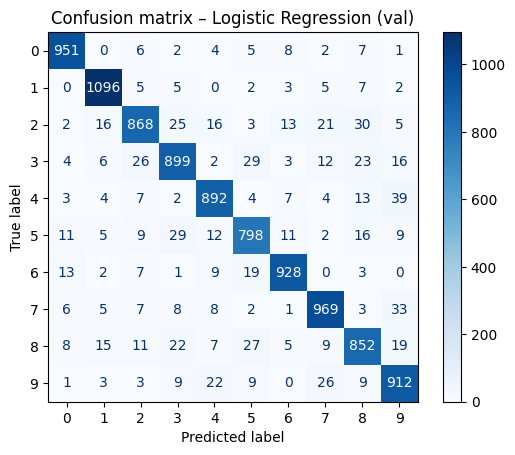

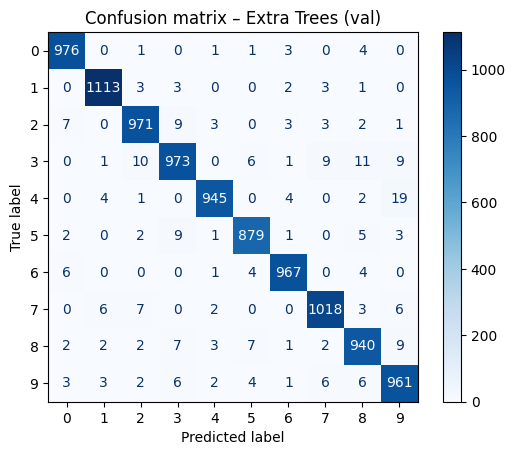


Extra Trees väljs som slutlig modell.


In [10]:
# Cell 26 – korrekt version
print(f"Val-accuracy Logistic Regression:    {logreg_val_acc:.4f}")
print(f"Val-accuracy Extra Trees (standard): {et_val_acc:.4f}")
print(f"Val-accuracy Extra Trees (bästa):    {best_val_acc:.4f}")

display_confusion_matrix(y_val, y_val_pred_logreg, title="Confusion matrix – Logistic Regression (val)")
display_confusion_matrix(y_val, y_val_pred_best,   title="Confusion matrix – Extra Trees (val)")

if best_val_acc > logreg_val_acc:
    print("\nExtra Trees väljs som slutlig modell.")
else:
    print("\nLogistic Regression väljs som slutlig modell.")

### Steg 6 – Utvärdera bästa modell på testdatan

Den modell som visade bäst resultat på valideringsdatan tränas nu om på 
all tillgänglig träningsdata (train + val) och utvärderas slutligen på testdatan.
Testdatan har inte berörts tidigare i flödet.

Jag slår ihop tränings- och valideringsdata, skalar om med samma scaler 
och tränar om Extra Trees-modellen med de hyperparametrar som valdes i Steg 5.
Slutligen genereras prediktioner på testdatan.

In [11]:
# 1. Slå ihop train + val
X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

# 2. Skala om – fit på train+val, transform på test
scaler.fit(X_trainval)
X_trainval_scaled = scaler.transform(X_trainval)
X_test_scaled_final = scaler.transform(X_test)

# 3. Träna om bästa modell på all train+val-data
best_et_final = ExtraTreesClassifier(
    n_estimators=best_et.n_estimators,
    max_depth=best_et.max_depth,
    max_features=best_et.max_features,
    random_state=42,
    n_jobs=-1
)
best_et_final.fit(X_trainval_scaled, y_trainval)

# 4. Prediktera på testdatan → definierar y_test_pred
y_test_pred = best_et_final.predict(X_test_scaled_final)

Här utvärderas modellens prestanda på testdatan med accuracy, confusion matrix 
och classification report. Avslutningsvis visualiseras några av de 
felklassificerade exemplen för att ge en bild av var modellen har svårast.

Test-accuracy (Extra Trees): 0.9719


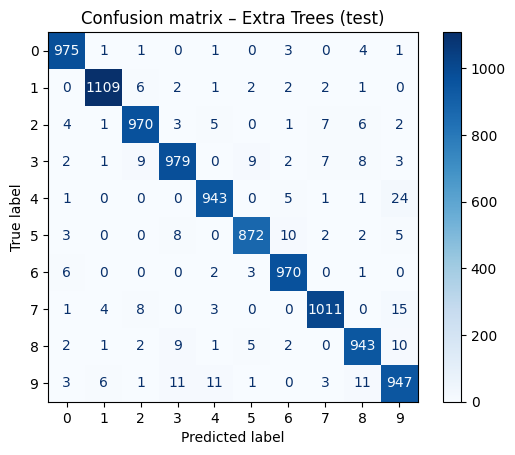

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       986
           1       0.99      0.99      0.99      1125
           2       0.97      0.97      0.97       999
           3       0.97      0.96      0.96      1020
           4       0.98      0.97      0.97       975
           5       0.98      0.97      0.97       902
           6       0.97      0.99      0.98       982
           7       0.98      0.97      0.97      1042
           8       0.97      0.97      0.97       975
           9       0.94      0.95      0.95       994

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



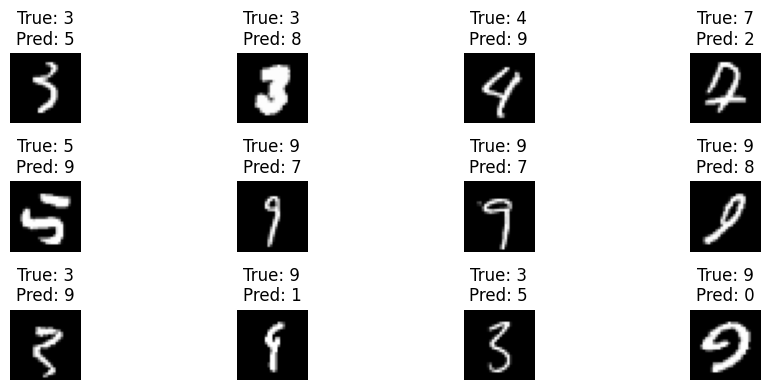

In [12]:
# 5. Accuracy, confusion matrix och classification report
test_acc = accuracy_score(y_test, y_test_pred)
print(f"Test-accuracy (Extra Trees): {test_acc:.4f}")
display_confusion_matrix(y_test, y_test_pred, title="Confusion matrix – Extra Trees (test)")
print(classification_report(y_test, y_test_pred))

# 6. Visualisera felklassificerade exempel ← din befintliga kod
mis_idx = np.where(y_test != y_test_pred)[0]
num_mis = min(12, len(mis_idx))

plt.figure(figsize=(10, 4))
for i in range(num_mis):
    idx = mis_idx[i]
    img = X_test[idx].reshape(28, 28)  # OBS: oskalad bild för visning
    plt.subplot(3, 4, i + 1)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title(f"True: {y_test[idx]}\nPred: {y_test_pred[idx]}")
plt.tight_layout()
plt.show()

Visualiseringarna av felklassificerade exempel ger en tydlig bild av var modellen 
har svårast – framför allt siffror som liknar varandra visuellt, exempelvis 4 och 9 
eller 3 och 8. Detta var förväntat beteende.

### Steg 7 – Spara modellen inför Streamlit

Jag sparar den tränade modellen och scalern med joblib så att de kan 
laddas in i en separat Streamlit-applikation för att göra prediktioner på ny data.

In [13]:
# spara den tränade modellen till disk
joblib.dump(best_et_final, "mnist_best_model.joblib")

# spara scalern – krävs för att skala ny data på samma sätt
joblib.dump(scaler, "mnist_scaler.joblib")

print("Modell och scaler sparade.")

Modell och scaler sparade.


Kommentar till Steg 7

- best_et_final är modellen tränad på train + val – den har sett all 
  tillgänglig träningsdata och är den som ska användas i produktion.
- scaler sparas tillsammans med modellen eftersom ny indata måste 
  genomgå exakt samma skalning som träningsdatan, annars blir prediktionerna fel.
- joblib är effektivt för att serialisera scikit-learn-objekt och 
  är det rekommenderade sättet att spara modeller i kursmaterialet.
- De sparade filerna mnist_best_model.joblib och mnist_scaler.joblib 
  laddas sedan in i Streamlit-applikationen med joblib.load().